<a href="https://colab.research.google.com/github/abuzar01440/abuzar-portfolio/blob/main/pwc_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Marketing
###  --> pwc Task 2

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
henriqueyamahata_bank_marketing_path = kagglehub.dataset_download('henriqueyamahata/bank-marketing')

print('Data source import complete.')


100%|██████████| 393k/393k [00:00<00:00, 96.3MB/s]

Extracting files...
Data source import complete.


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path = os.path.join(henriqueyamahata_bank_marketing_path, 'bank-additional-full.csv')


In [ ]:
df = pd.read_csv(file_path, delimiter =";")
df.head(3)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
df.shape

(41176, 21)

In [ ]:
!pip install ydata-profiling

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 392.1/392.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.9/547.9 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.9/232.9 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 94.0 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=e590fb692d5b412831dd74648c986b2eae9c51214c7bb8c8d1c8dc2f163ac9ea
  Stored in directory: /root/.cache/pip/wheels/8d/55/1a/19cd535375ed1ede0c996405ebffe34b196d78e2d9545723a2
Successfully built htmlmin


In [ ]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Profiling Report")

In [ ]:
profile

In [ ]:
df_str = df.select_dtypes(include=['object']).columns
df_str

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for encode in df_str:
  print(encode)
  df[encode] = le.fit_transform(df[encode])

print("Done")


job
marital
education
default
housing
loan
contact
month
day_of_week
poutcome
y
Done


In [ ]:
df_str = df.select_dtypes(include=['object']).columns
df_str

Index([], dtype='object')

In [ ]:
X = df.drop('y', axis=1)
y = df['y']
from sklearn.model_selection import train_test_split
# data paritiion
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'shape of X_train: {X_train.shape} & shape of y_train {y_train.shape}')
print(f'shape of y_train: {y_train.shape} and shape of y_test {y_test.shape}' )

shape of X_train: (32940, 20) & shape of y_train (32940,)
shape of y_train: (32940,) and shape of y_test (8236,)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ML

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
classifer = AdaBoostClassifier(n_estimators=169)
classifer.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=169)

In [ ]:
y_predict = classifer.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
print(round(accuracy_score(y_test, y_predict),4))
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predict))
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_predict))

0.9075
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7308
           1       0.63      0.43      0.51       928

    accuracy                           0.91      8236
   macro avg       0.78      0.70      0.73      8236
weighted avg       0.90      0.91      0.90      8236

[[7073  235]
 [ 527  401]]


In [ ]:
feature_importances = classifer.feature_importances_
feature_columns = X.columns
feature_df = pd.DataFrame({'Feature': feature_columns, 'Importance': feature_importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)


In [ ]:
feature_df

,Feature,Importance
10,duration,0.494463
19,nr.employed,0.206758
15,emp.var.rate,0.062271
17,cons.conf.idx,0.057535
8,month,0.045382
12,pdays,0.031743
14,poutcome,0.031436
16,cons.price.idx,0.026282
0,age,0.016886
18,euribor3m,0.015294


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Importance'].plot(kind='hist', bins=20, title='Importance')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2.plot(kind='scatter', x='index', y='Importance', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_4['Importance'].plot(kind='line', figsize=(8, 4), title='Importance')
plt.gca().spines[['top', 'right']].set_visible(False)

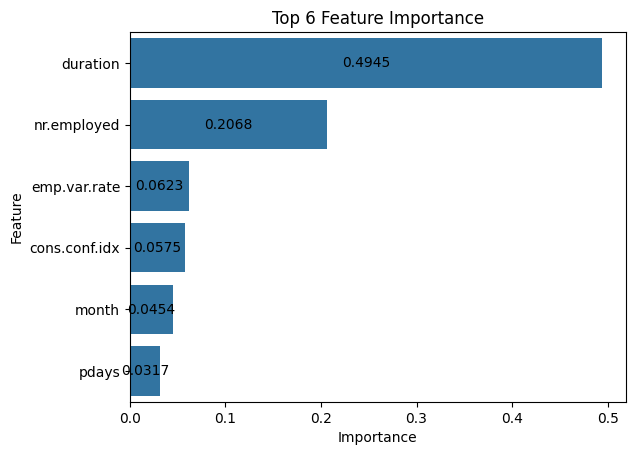

In [ ]:
ax=sns.barplot(x='Importance', y='Feature', data=feature_df[:6] )
# annotate
for p in ax.patches:
  ax.annotate(f'{p.get_width():.4f}',
                (p.get_x() + p.get_width() / 2, p.get_y() + p.get_height() / 2),  # Center coordinates
                ha='center', va='center',  # Center alignment
                xytext=(0, 0), textcoords='offset points')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 6 Feature Importance')
plt.show()

In [ ]:
# save the model
import pickle as pkl
with open('classifier_model.pkl', 'wb') as f:
    pkl.dump(classifer, f)

#Neural netwok

In [ ]:
from tensorflow.keras import Sequential
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
model = Sequential([
    Dense(X_train.shape[1] + 1, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='elu'),
    Dense(128, activation='elu'),
    Dropout(.06),
    Dense(256, activation='elu'),
    Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 21)                  │             441 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           1,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 43,450 (169.73 KB)

 Trainable params: 43,450 (169.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf

try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()  # TPU detection
    print('Running on TPU ', tpu.master())
except ValueError:
    tpu = None

if tpu:
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
else:
    strategy = tf.distribute.get_strategy()  # Default strategy for CPU and GPU

print("REPLICAS: ", strategy.num_replicas_in_sync)

Running on TPU  
REPLICAS:  8


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Define the strategy
strategy = tf.distribute.MirroredStrategy()
print(f"Number of devices: {strategy.num_replicas_in_sync}")

# Define batch size
BATCH_SIZE_PER_REPLICA = 32
global_batch_size = BATCH_SIZE_PER_REPLICA * strategy.num_replicas_in_sync

# Convert your data to tf.data.Dataset format BEFORE applying the strategy
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.batch(global_batch_size)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(global_batch_size)

# Use strategy.experimental_distribute_dataset instead of distribute_datasets_from_function
train_dist_dataset = strategy.experimental_distribute_dataset(train_dataset)
test_dist_dataset = strategy.experimental_distribute_dataset(test_dataset)

model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, save_weights_only=False)
early_stopping = EarlyStopping(patience=39, restore_best_weights=True)
schedular = ReduceLROnPlateau(patience=6, factor=0.1, min_lr=0.00001, verbose=1)

with strategy.scope():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.06),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.1),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

# Model fitting
history = model.fit(
    train_dataset,
    epochs=126,
    validation_data=test_dataset,
    callbacks=[model_checkpoint, early_stopping, schedular]
)

Number of devices: 1
Epoch 1/126
1029/1030 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8848 - loss: 0.4116

1030/1030 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8848 - loss: 0.4115 - val_accuracy: 0.8872 - val_loss: 0.3225 - learning_rate: 0.1000
Epoch 2/126
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8881 - loss: 0.3743 - val_accuracy: 0.8873 - val_loss: 0.3530 - learning_rate: 0.1000
Epoch 3/126
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8889 - loss: 0.3587 - val_accuracy: 0.8873 - val_loss: 0.3529 - learning_rate: 0.1000
Epoch 4/126
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8893 - loss: 0.3619 - val_accuracy: 0.8873 - val_loss: 0.3526 - learning_rate: 0.1000
Epoch 5/126
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8893 - loss: 0.3542 - val_accuracy: 0.8873 - val_loss: 0.3531 - learning_rate: 0.1000
Epoch 6/126
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8893 - loss: 0.3495 - val_accuracy: 0.8873 - val_loss: 0.3531 - learning_rate: 0.1000
Epoch 7/126
1012/1030 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8894 - loss: 

In [ ]:
print("training complete")

training complete


In [ ]:
model.evaluate(test_dataset)

258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8881 - loss: 0.3272


[0.3224588632583618, 0.8872025012969971]

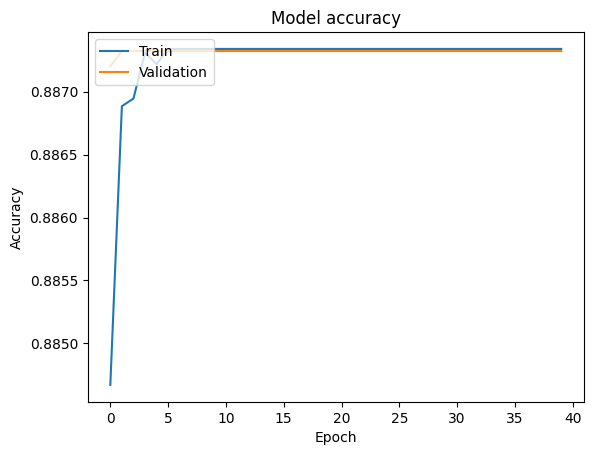

In [ ]:
def plot_history(history):
    # Plot training & validation accuracy values
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()
plot_history(history)

In [ ]:
# model if 0.5 equal or greater =1 else =0 for evaluation

y_predict = model.predict(X_test)
y_predict = np.where(y_predict >= 0.5, 1, 0)

258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
y_predict=y_predict.flatten()
y_predict

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
print(round(accuracy_score(y_test, y_predict),4))
confusion_matrix(y_test, y_predict)

0.8872


array([[7307,    1],
       [ 928,    0]])

In [ ]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      7308
           1       0.00      0.00      0.00       928

    accuracy                           0.89      8236
   macro avg       0.44      0.50      0.47      8236
weighted avg       0.79      0.89      0.83      8236



In [ ]:
model.save("best_")